# RL Agent Training Tutorial

This notebook guides you through training a reinforcement learning agent to learn quantum noise models. We'll start with a simple single-circuit example and gradually build up to training on complex multi-qubit datasets.

## 1. Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch

# Import RL Noise components
from rlnoise.config import (
    DatasetConfig,
    NoiseConfig,
    GateSpecificNoise,
    GymEnvConfig,
    RewardConfig,
    AgentConfig,
)
from rlnoise.dataset import DatasetGenerator, CircuitDataset
from rlnoise.circuit_encoder import CircuitEncoder
from rlnoise.gym_env import QuantumCircuitEnv
from rlnoise.rl_agent import RLAgent

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)


## 2. Understanding the Training Components

Before we start training, let's understand the key components:

### 2.1 Neural Network Architecture

The agent uses a **CNN Feature Extractor** that processes the sliding window observations:
- **Input**: Sliding window of circuit moments (shape: encoding_dim × n_qubits × kernel_size)
- **Conv2D Layer**: Extracts spatial features from the circuit
- **Flatten + Linear**: Maps features to a fixed dimension
- **Policy & Value Networks**: Separate networks for action selection and value estimation

### 2.2 Training Callback

The callback monitors training progress:
- Periodically evaluates the agent on train/validation sets
- Tracks metrics (reward, trace distance, etc.)
- Saves the best model based on validation performance
- Provides real-time feedback during training

### 2.3 Agent Configuration

The `AgentConfig` controls:
- **features_dim**: Output dimension of feature extractor
- **filter_size**: CNN filter width
- **n_filters**: Number of CNN filters
- **n_steps**: Steps before PPO update
- **batch_size**: Batch size for training
- **learning_rate**: Optimizer learning rate

## 3. Simple Training Example: Single Circuit

Let's start with the simplest possible case: a single 1-qubit circuit with only one source of coherent noise.

### 3.1. Create a Simple Dataset

In [2]:
# Create a very simple dataset - 1 circuit, 1 qubit
simple_dataset_config = DatasetConfig(
    n_circuits=1,
    moments=8,
    qubits=1,
    primitive_gates=["rx", "rz"],
    clifford=True
)

noise_parameter = 0.06  # coherent noise level for the simple model

# Simple noise model - only depolarizing with a clear value
simple_noise_config = NoiseConfig(
    noise_list=[
        GateSpecificNoise(gate="rx", noise_channel="coherent_x", noise_parameter=noise_parameter),
        GateSpecificNoise(gate="rz", noise_channel="coherent_x", noise_parameter=noise_parameter),
    ]
)

# Generate the dataset
generator = DatasetGenerator(simple_dataset_config, simple_noise_config)
simple_dataset = generator.generate(verbose=True)

print(simple_dataset)

[Qibo 0.2.23|INFO|2026-04-02 20:00:55]: Using numpy backend on /CPU:0


Generating 1 circuits...
Applying noise model...
Encoding circuits...
Dataset generated.

  CircuitDataset
    â€¢ Circuits:            1
    â€¢ Qubits:              1
    â€¢ Moments (depth):     8
    â€¢ Encoding dimension:  8
    â€¢ Circuit shape:       (8, 1, 8)


### 3.2. Create Environment and Encoder

In [3]:
# Create encoder
simple_encoder = CircuitEncoder(primitive_gates=["rx", "rz"])

# Environment configuration
simple_env_config = GymEnvConfig(
    kernel_size=3,
    action_space_max_value=0.1,     # Max noise per step: 0.1
    val_split=0.0,              # No validation split for single circuit
)

# Reward configuration
simple_reward_config = RewardConfig(
    metric="trace",
    function="inverted_squared",
    alpha=20.0
)

# Create environment
simple_env = QuantumCircuitEnv(
    dataset=simple_dataset,
    encoder=simple_encoder,
    env_config=simple_env_config,
    reward_config=simple_reward_config,
)

print(simple_env)

QuantumCircuitEnv:
  Dataset:
    circuits: 1 (1 train, 0 val)
    qubits: 1
  Encoder:
    primitive_gates: ['rx', 'rz']
  Environment:
    observation_space: (8, 1, 3)
    action_space: (1, 4)
    kernel_size: 3
    action_max: 0.1
    only_depolarizing: False
  Reward:
    metric: trace
    function: inverted_squared
    alpha: 20.0


### 3.3. Configure the Agent

For this simple task, we'll use a small neural network.

In [4]:
# Agent configuration - small network for simple task
simple_agent_config = AgentConfig(
    policy="MlpPolicy",
    features_dim=32,        # Number of features extracted by CNN
    filter_size=2,          # Size of convolutional filters
    n_filters=16,           # Number of filters
    pi_net_arch=[32],       # Simple policy network
    vf_net_arch=[32],       # Simple value network
    n_steps=400,            # Update every 400 steps
    batch_size=50,          # Small batches (has to divide steps)
    learning_rate=1e-4,
    verbose=1
)

simple_agent = RLAgent(
    env=simple_env,
    agent_config=simple_agent_config
)

print(simple_agent)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
RLAgent (PPO)
  Observation space:    (8, 1, 3)
  Action space:         (1, 4)
  Action range:         [0.000, 1.000]
------------------------------------------------------------
  Total parameters:     3,609
  Trainable parameters: 3,609
------------------------------------------------------------
  Features dim:         32
  CNN filters:          16
  CNN filter size:      2
  Policy net arch:      [32]
  Value net arch:       [32]
------------------------------------------------------------
  Learning rate:        0.0001
  Batch size:           50
  N steps:              400
  Gamma:                0.99


For more information about the neural network:

In [5]:
simple_agent.print_network()

NEURAL NETWORK ARCHITECTURE

ActorCriticPolicy(
  (features_extractor): CNNFeaturesExtractor(
    (conv1): Conv2d(8, 16, kernel_size=(1, 2), stride=(1, 1))
    (cnn): Sequential(
      (0): Conv2d(8, 16, kernel_size=(1, 2), stride=(1, 1))
      (1): ReLU()
      (2): Flatten(start_dim=1, end_dim=-1)
    )
    (linear): Sequential(
      (0): Linear(in_features=32, out_features=32, bias=True)
      (1): ReLU()
    )
  )
  (pi_features_extractor): CNNFeaturesExtractor(
    (conv1): Conv2d(8, 16, kernel_size=(1, 2), stride=(1, 1))
    (cnn): Sequential(
      (0): Conv2d(8, 16, kernel_size=(1, 2), stride=(1, 1))
      (1): ReLU()
      (2): Flatten(start_dim=1, end_dim=-1)
    )
    (linear): Sequential(
      (0): Linear(in_features=32, out_features=32, bias=True)
      (1): ReLU()
    )
  )
  (vf_features_extractor): CNNFeaturesExtractor(
    (conv1): Conv2d(8, 16, kernel_size=(1, 2), stride=(1, 1))
    (cnn): Sequential(
      (0): Conv2d(8, 16, kernel_size=(1, 2), stride=(1, 1))
     

### 3.4. Train the Agent

Now let's create the agent and train it!

In [6]:
import importlib, rlnoise.callback, rlnoise.rl_agent
importlib.reload(rlnoise.callback)
importlib.reload(rlnoise.rl_agent)
from rlnoise.rl_agent import RLAgent

# Re-create agent to pick up reloaded modules
simple_agent = RLAgent(env=simple_env, agent_config=simple_agent_config)

# Train the agent
results = simple_agent.train(
    total_timesteps=20001,           # Short training for simple task
    check_freq=2000,                 # Performance evaluation frequency (in steps)
    save_best=True,                 # Don't save for this demo
    progress_bar=True,
    verbose=True,                    # Print avg reward at each eval step
    deterministic_train_eval=True,   # Full deterministic pass over train set (False = faster rollout accumulation)
)


Output()

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


Step    2000 | Train reward: 7.1285 Â± 0.0000  trace: 0.0837 Â± 0.0000  |  Val reward: 0.0000 Â± 0.0000  trace: 0.0000 Â± 0.0000


Step    4000 | Train reward: 9.2497 Â± 0.0000  trace: 0.0735 Â± 0.0000  |  Val reward: 0.0000 Â± 0.0000  trace: 0.0000 Â± 0.0000


Step    6000 | Train reward: 32.2954 Â± 0.0000  trace: 0.0393 Â± 0.0000  |  Val reward: 0.0000 Â± 0.0000  trace: 0.0000 Â± 0.0000


...

Step   14000 | Train reward: 2204.4911 Â± 0.0000  trace: 0.0048 Â± 0.0000  |  Val reward: 0.0000 Â± 0.0000  trace: 0.0000 Â± 0.0000


Step   16000 | Train reward: 118120.7018 Â± 0.0000  trace: 0.0007 Â± 0.0000  |  Val reward: 0.0000 Â± 0.0000  trace: 0.0000 Â± 0.0000


Step   18000 | Train reward: 332.0356 Â± 0.0000  trace: 0.0123 Â± 0.0000  |  Val reward: 0.0000 Â± 0.0000  trace: 0.0000 Â± 0.0000


Step   20000 | Train reward: 142.3919 Â± 0.0000  trace: 0.0187 Â± 0.0000  |  Val reward: 0.0000 Â± 0.0000  trace: 0.0000 Â± 0.0000


Loaded best model weights.


### 3.5. Analyze Training Results

The error bars are not shown as only one sample is available

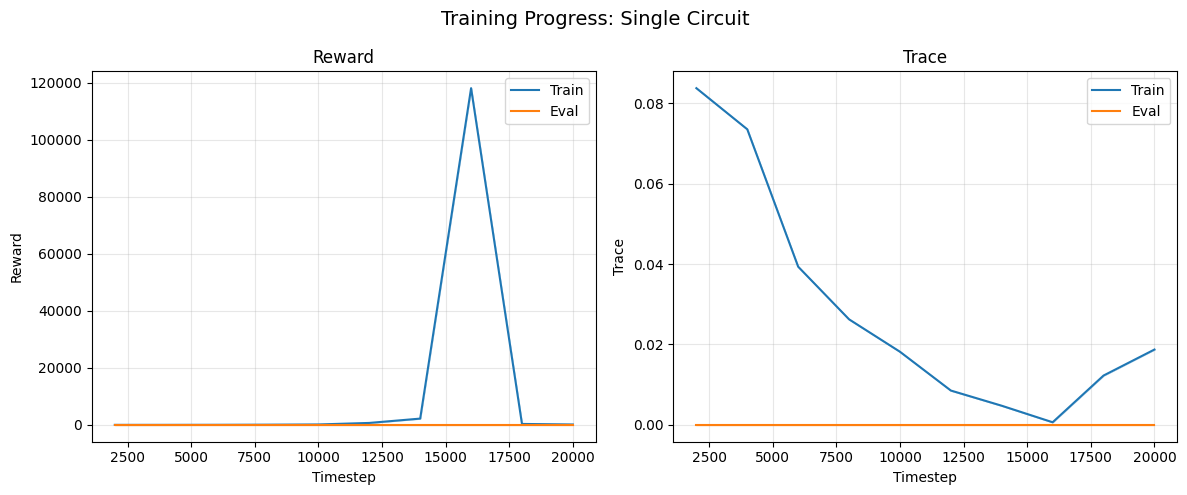

In [ ]:
from rlnoise.visualization import plot_training_dashboard

fig = plot_training_dashboard(
    results,
    title="Training Progress: Single Circuit",
    filepath="training_results/single_circuit_dashboard.png",
    show_reward=True,
    show_trace_distance=True,
    show_fidelity=True,
)
plt.show()


### 3.6. Test the Trained Agent

Let's see what noise parameters the agent learned to apply!

In [8]:
# Reset environment and run an episode with the trained agent
obs, info = simple_env.reset()

actions_taken = []
step = 0
terminated = False

print("Target noise: ", noise_parameter)
print()

while not terminated:
    # Get action from trained agent
    action = simple_agent.predict(obs, deterministic=True)
    actions_taken.append(action)
    
    # Show what action was taken
    
    x_action = action[0, 0]  # Index 0 is coherent X
    print(f"Step {step}: Coherent rx action = {x_action:.4f} → noise = {x_action * 0.1:.4f}")

    print("Full action:\n", action)
    
    # Take step
    obs, reward, terminated, truncated, info = simple_env.step(action)
    step += 1

Target noise:  0.06

Step 0: Coherent rx action = 0.5896 → noise = 0.0590
Full action:
 [[0.5896033 0.        0.        0.       ]]
Step 1: Coherent rx action = 0.6159 → noise = 0.0616
Full action:
 [[0.615891 0.       0.       0.      ]]
Step 2: Coherent rx action = 0.6055 → noise = 0.0605
Full action:
 [[0.6054738 0.        0.        0.       ]]
Step 3: Coherent rx action = 0.5990 → noise = 0.0599
Full action:
 [[0.59896 0.      0.      0.     ]]
Step 4: Coherent rx action = 0.6037 → noise = 0.0604
Full action:
 [[0.60373944 0.         0.         0.        ]]
Step 5: Coherent rx action = 0.5916 → noise = 0.0592
Full action:
 [[0.59155726 0.         0.         0.        ]]
Step 6: Coherent rx action = 0.5966 → noise = 0.0597
Full action:
 [[0.5966021 0.        0.        0.       ]]
Step 7: Coherent rx action = 0.5998 → noise = 0.0600
Full action:
 [[0.5997762 0.        0.        0.       ]]


## 4. Training with Multiple Circuits

Now let's scale up to multiple circuits to see how the agent generalizes.

### 4.1. Create Multi-Circuit Dataset

In [9]:
multi_dataset_config = DatasetConfig(
    n_circuits=100,
    moments=10,
    qubits=1,
    primitive_gates=["rz", "rx"],
    clifford=True,
    distributed_clifford=False,
    mixed=False,
)

# More complex noise model with multiple noise channels and different parameters on rx and rz, matching experiments/simulation/1q/config.json
multi_noise_config = NoiseConfig(
    noise_list=[
        GateSpecificNoise(gate="rz", noise_channel="depolarizing",  noise_parameter=0.02),
        GateSpecificNoise(gate="rx", noise_channel="damping",       noise_parameter=0.03),
        GateSpecificNoise(gate="rx", noise_channel="coherent_x",    noise_parameter=0.04),
        GateSpecificNoise(gate="rz", noise_channel="coherent_z",    noise_parameter=0.02),
    ]
)

generator = DatasetGenerator(multi_dataset_config, multi_noise_config)
multi_dataset = generator.generate(verbose=True)

print(multi_dataset)


Generating 100 circuits...
Applying noise model...
Encoding circuits...
Dataset generated.

  CircuitDataset
    â€¢ Circuits:            100
    â€¢ Qubits:              1
    â€¢ Moments (depth):     10
    â€¢ Encoding dimension:  8
    â€¢ Circuit shape:       (10, 1, 8)


### 4.2. Setup Environment with Validation Split

In [10]:

multi_encoder = CircuitEncoder(primitive_gates=["rz", "rx"])

# Env config from 1q config.json
multi_env_config = GymEnvConfig(
    kernel_size=3,
    action_penalty=0.0,
    action_space_max_value=0.06,
    enable_only_depolarizing=False,
    val_split=0.2,
)

multi_reward_config = RewardConfig(
    metric="trace",
    function="inverted_squared",
    alpha=20.0,
)

multi_env = QuantumCircuitEnv(
    dataset=multi_dataset,
    encoder=multi_encoder,
    env_config=multi_env_config,
    reward_config=multi_reward_config,
)

print(multi_env)


QuantumCircuitEnv:
  Dataset:
    circuits: 100 (80 train, 20 val)
    qubits: 1
  Encoder:
    primitive_gates: ['rz', 'rx']
  Environment:
    observation_space: (8, 1, 3)
    action_space: (1, 4)
    kernel_size: 3
    action_max: 0.06
    only_depolarizing: False
  Reward:
    metric: trace
    function: inverted_squared
    alpha: 20.0


### 4.3. Train with Callback Monitoring

In [11]:

# Agent config from 1q config.json:
#   policy=MlpPolicy, features_dim=32, filter_size=1, n_filters=16,
#   net_arch pi=[32,32] vf=[32,32], nn_update_steps=1000, batch_size=200
multi_agent_config = AgentConfig(
    policy="MlpPolicy",
    features_dim=32,
    filter_size=1,
    n_filters=16,
    pi_net_arch=[32, 32],
    vf_net_arch=[32, 32],
    n_steps=2000,
    batch_size=200,
    learning_rate=1e-4,
)

multi_agent = RLAgent(
    env=multi_env,
    agent_config=multi_agent_config
)

print(multi_agent)

multi_results = multi_agent.train(
    total_timesteps=200000,
    check_freq=10000,
    save_best=True,
    progress_bar=True,
    verbose=True,
    save_path="agents/1q_agent",
)


Output()

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
RLAgent (PPO)
  Observation space:    (8, 1, 3)
  Action space:         (1, 4)
  Action range:         [0.000, 1.000]
------------------------------------------------------------
  Total parameters:     6,105
  Trainable parameters: 6,105
------------------------------------------------------------
  Features dim:         32
  CNN filters:          16
  CNN filter size:      1
  Policy net arch:      [32, 32]
  Value net arch:       [32, 32]
------------------------------------------------------------
  Learning rate:        0.0001
  Batch size:           200
  N steps:              2000
  Gamma:                0.99


Step   10000 | Train reward: 3.2243 Â± 0.8063  trace: 0.1275 Â± 0.0166  |  Val reward: 3.1871 Â± 0.8635  trace: 0.1300 Â± 0.0251
Model saved in agents/1q_agent


Step   20000 | Train reward: 3.2988 Â± 0.7912  trace: 0.1257 Â± 0.0151  |  Val reward: 3.2596 Â± 0.8411  trace: 0.1280 Â± 0.0227
Model saved in agents/1q_agent


Step   30000 | Train reward: 3.2884 Â± 0.7936  trace: 0.1260 Â± 0.0153  |  Val reward: 3.2488 Â± 0.8454  trace: 0.1283 Â± 0.0230


...

Step  170000 | Train reward: 17.6459 Â± 12.0540  trace: 0.0581 Â± 0.0117  |  Val reward: 16.1138 Â± 6.3151  trace: 0.0598 Â± 0.0147


Step  180000 | Train reward: 23.0473 Â± 16.3028  trace: 0.0518 Â± 0.0120  |  Val reward: 22.1553 Â± 10.3249  trace: 0.0528 Â± 0.0165


Step  190000 | Train reward: 14.3735 Â± 7.7805  trace: 0.0634 Â± 0.0123  |  Val reward: 13.8548 Â± 5.4122  trace: 0.0646 Â± 0.0165


Step  200000 | Train reward: 24.0220 Â± 22.4671  trace: 0.0518 Â± 0.0117  |  Val reward: 21.2241 Â± 8.7935  trace: 0.0527 Â± 0.0140


Loaded best model weights from agents/1q_agent


### 4.4. Analyze Multi-Circuit Training

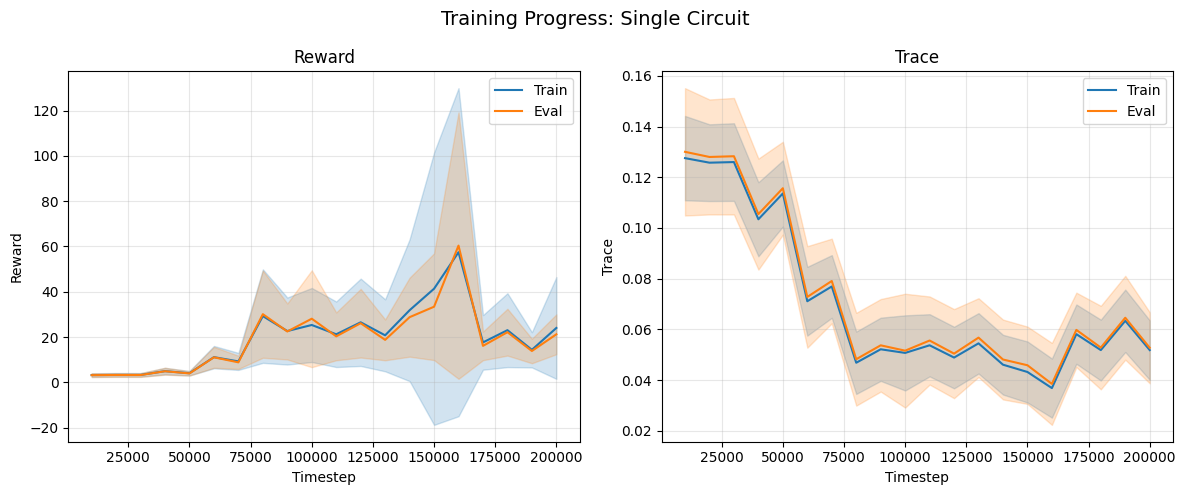

In [ ]:
fig = plot_training_dashboard(
    multi_results,
    title="Training Progress: Single Circuit (complex)",
    filepath="training_results/single_circuit_complex_dashboard.png",
    show_reward=True,
    show_trace_distance=True,
    show_fidelity=True,
)
plt.show()


## 5. Advanced: 3-Qubit Training

Now for the final challenge - training on 3-qubit circuits with multiple noise types!

### 5.1. Load 3-Qubit Dataset

We'll use a pre-generated 3-qubit dataset from the examples folder or generate it if not present. The characteristics of the dataset are the same used in the 3 qubit experiment.

In [2]:

DATASET_3Q_PATH = Path("example_datasets/dataset_3q_large.npz")

if DATASET_3Q_PATH.exists():
    print(f"Loading existing dataset from '{DATASET_3Q_PATH}'...")
    dataset_3q = CircuitDataset.load(str(DATASET_3Q_PATH))
else:
    print("Dataset not found, generating...")

    dataset_config_3q = DatasetConfig(
        n_circuits=800,
        moments=20,
        qubits=3,
        primitive_gates=["rz", "rx", "cz"],
        clifford=False,
        distributed_clifford=False,
        mixed=True,
    )

    noise_config_3q = NoiseConfig(
        noise_list=[
            GateSpecificNoise(gate="rz", noise_channel="depolarizing", noise_parameter=0.02),
            GateSpecificNoise(gate="cz", noise_channel="depolarizing", noise_parameter=0.02),
            GateSpecificNoise(gate="rx", noise_channel="damping",       noise_parameter=0.03),
            GateSpecificNoise(gate="cz", noise_channel="damping",       noise_parameter=0.03),
            GateSpecificNoise(gate="rx", noise_channel="coherent_x",    noise_parameter=0.04),
            GateSpecificNoise(gate="rz", noise_channel="coherent_z",    noise_parameter=0.03),
        ]
    )

    print(noise_config_3q)

    generator_3q = DatasetGenerator(dataset_config_3q, noise_config_3q)
    dataset_3q = generator_3q.generate(verbose=True)

    dataset_3q.save(str(DATASET_3Q_PATH))
    print(f"Dataset saved to '{DATASET_3Q_PATH}'")

print(dataset_3q)


Loading existing dataset from 'example_datasets\dataset_3q_large.npz'...

  CircuitDataset
    â€¢ Circuits:            800
    â€¢ Qubits:              3
    â€¢ Moments (depth):     20
    â€¢ Encoding dimension:  8
    â€¢ Circuit shape:       variable (sample: (20, 3, 8))


### 5.2. Setup 3-Qubit Environment

In [3]:
# Create encoder for 3-qubit circuits
encoder_3q = CircuitEncoder(primitive_gates=["rx", "rz", "cz"])

# Environment configuration
env_config_3q = GymEnvConfig(
    kernel_size=3,
    action_space_max_value=0.06,  # Max noise per step: 0.06
    val_split=0.2,
    enable_only_depolarizing=False,  # Allow all noise types
)

# Reward configuration
reward_config_3q = RewardConfig(
    metric="trace",
    function="inverted_squared",
    alpha=20.0
)

# Create environment
env_3q = QuantumCircuitEnv(
    dataset=dataset_3q,
    encoder=encoder_3q,
    env_config=env_config_3q,
    reward_config=reward_config_3q,
)

print(env_3q)

QuantumCircuitEnv:
  Dataset:
    circuits: 800 (640 train, 160 val)
    qubits: 3
  Encoder:
    primitive_gates: ['rx', 'rz', 'cz']
  Environment:
    observation_space: (8, 3, 3)
    action_space: (3, 4)
    kernel_size: 3
    action_max: 0.06
    only_depolarizing: False
  Reward:
    metric: trace
    function: inverted_squared
    alpha: 20.0


### 5.3. Configure Agent for 3-Qubit Circuits

For 3-qubit circuits, we need a larger network to handle the complexity.

In [4]:

# Agent config from 3q_high config.json:
#   policy=MlpPolicy, features_dim=64, filter_size=1, n_filters=32,
#   net_arch pi=[32,32] vf=[32,32], nn_update_steps=2000, batch_size=400
agent_config_3q = AgentConfig(
    policy="MlpPolicy",
    features_dim=64,
    filter_size=1,
    n_filters=32,
    pi_net_arch=[32, 32],
    vf_net_arch=[32, 32],
    n_steps=2000,
    batch_size=100,
    learning_rate=1e-4,
)

agent_3q = RLAgent(
    env=env_3q,
    agent_config=agent_config_3q
)

print(agent_3q)


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
RLAgent (PPO)
  Observation space:    (8, 3, 3)
  Action space:         (3, 4)
  Action range:         [0.000, 1.000]
------------------------------------------------------------
  Total parameters:     13,721
  Trainable parameters: 13,721
------------------------------------------------------------
  Features dim:         64
  CNN filters:          32
  CNN filter size:      1
  Policy net arch:      [32, 32]
  Value net arch:       [32, 32]
------------------------------------------------------------
  Learning rate:        0.0001
  Batch size:           100
  N steps:              2000
  Gamma:                0.99


### 5.4. Train 3-Qubit Agent

This will take longer due to the increased complexity. For a proper training order of 10^6 timestps should be executed.

In [16]:

# Train: 2 000 000 steps, eval every 10 000 (from 3q_high callback.check_freq)
results_3q = agent_3q.train(
    total_timesteps=4000000,
    check_freq=20000,
    save_best=True,
    progress_bar=True,
    verbose=True,
    save_path="agents/3q_agent_long_training_bis",
    history_path="training_results/3q_history_bis",   # saves training_results/3q_history.npz automatically
)


Output()

Step   20000 | Train reward: 0.1689 Â± 0.1091  trace: 0.6128 Â± 0.1576  |  Val reward: 0.1687 Â± 0.1144  trace: 0.6153 Â± 0.1609
Model saved in agents/3q_agent_long_training_bis


Step   40000 | Train reward: 0.1169 Â± 0.0636  trace: 0.7047 Â± 0.1395  |  Val reward: 0.1192 Â± 0.0720  trace: 0.7031 Â± 0.1451


Step   60000 | Train reward: 0.1175 Â± 0.0645  trace: 0.7037 Â± 0.1405  |  Val reward: 0.1198 Â± 0.0716  trace: 0.7019 Â± 0.1460


Step   80000 | Train reward: 0.1481 Â± 0.0903  trace: 0.6433 Â± 0.1520  |  Val reward: 0.1490 Â± 0.0982  trace: 0.6447 Â± 0.1558


...

Step 3940000 | Train reward: 2.1742 Â± 3.5737  trace: 0.3397 Â± 0.1940  |  Val reward: 2.0338 Â± 3.4451  trace: 0.3399 Â± 0.1920


Step 3960000 | Train reward: 2.2326 Â± 3.7128  trace: 0.3366 Â± 0.1933  |  Val reward: 2.1495 Â± 3.9407  trace: 0.3368 Â± 0.1906


Step 3980000 | Train reward: 2.1501 Â± 3.5750  trace: 0.3394 Â± 0.1934  |  Val reward: 1.9879 Â± 3.3493  trace: 0.3395 Â± 0.1906


Step 4000000 | Train reward: 2.2567 Â± 3.7378  trace: 0.3382 Â± 0.1940  |  Val reward: 2.1266 Â± 3.6765  trace: 0.3380 Â± 0.1912


Loaded best model weights from agents/3q_agent_long_training_bis
Training history saved to training_results/3q_history_bis.npz


### 5.5. Save Training History and Experiment Configuration

After training, you can persist both the full training history and the experiment configuration so that plots can be reproduced later without retraining.

- **Training history** (`.npz`) — saved automatically by passing `history_path` to `train()`.  
- **Experiment configuration** (`.json`) — saved via `ExperimentConfig.to_json_file()`.


In [6]:

from rlnoise.config import ExperimentConfig
from rlnoise.callback import TrainingCallback
from rlnoise.visualization import plot_training_dashboard

# ── Build experiment configuration from this session's config objects ─────────
# Note: dataset_config_3q and noise_config_3q are only in scope when the
# dataset was generated (not loaded from disk) in this session.
# Fallback: reconstruct them from the known example_datasets parameters.
if "dataset_config_3q" not in dir():
    dataset_config_3q = DatasetConfig(
        n_circuits=800, moments=20, qubits=3,
        primitive_gates=["rz", "rx", "cz"],
        clifford=False, distributed_clifford=False, mixed=True,
    )
if "noise_config_3q" not in dir():
    noise_config_3q = NoiseConfig(
        noise_list=[
            GateSpecificNoise(gate="rz", noise_channel="depolarizing", noise_parameter=0.02),
            GateSpecificNoise(gate="cz", noise_channel="depolarizing", noise_parameter=0.02),
            GateSpecificNoise(gate="rx", noise_channel="damping",       noise_parameter=0.03),
            GateSpecificNoise(gate="cz", noise_channel="damping",       noise_parameter=0.03),
            GateSpecificNoise(gate="rx", noise_channel="coherent_x",    noise_parameter=0.04),
            GateSpecificNoise(gate="rz", noise_channel="coherent_z",    noise_parameter=0.03),
        ]
    )

experiment_3q = ExperimentConfig(
    dataset=dataset_config_3q,
    noise=noise_config_3q,
    gym_env=env_config_3q,
    reward=reward_config_3q,
    agent=agent_config_3q,
)

# ── Save configuration as JSON ────────────────────────────────────────────────
config_path = "training_results/3q_experiment.json"
experiment_3q.to_json_file(config_path)
print(f"Experiment configuration saved to '{config_path}'")

# ── The training history .npz was already saved by train() above ──────────────
# It lives at training_results/3q_history.npz
print("Training history saved to 'training_results/3q_history.npz'")


Experiment configuration saved to 'training_results/3q_experiment.json'
Training history saved to 'training_results/3q_history.npz'


### 5.6. Reload and Plot (Standalone)

Training history is stored as a plain NumPy `.npz` file; the experiment configuration is stored as JSON. Both can be loaded independently — no environment or agent required.


Loaded 200 evaluation checkpoints
Metric    : trace
Best reward: 2.8037
Qubits    : 3   Train circuits: 640   Val circuits: 160


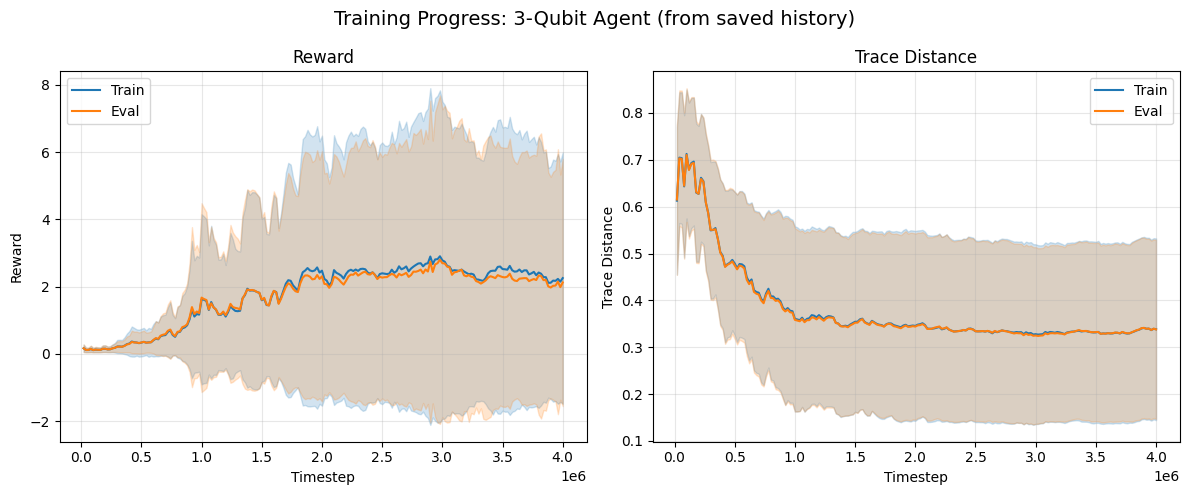


Reloaded dataset config : 
  DatasetConfig
    â€¢ Circuits:       800
    â€¢ Qubits:         3
    â€¢ Moments:        20
    â€¢ Type:           Mixed (Clifford + Arbitrary)
    â€¢ Gates:          [rz, rx, cz]

Reloaded agent config   : policy='MlpPolicy' features_dim=64 filter_size=1 n_filters=32 pi_net_arch=[32, 32] vf_net_arch=[32, 32] n_steps=2000 batch_size=100 learning_rate=0.0001 gamma=0.99 clip_range=0.2 verbose=1


In [9]:

# ── Load history from disk (no re-training needed) ───────────────────────────
loaded_history = TrainingCallback.load_history("training_results/3q_history")

print(f"Loaded {len(loaded_history['timesteps'])} evaluation checkpoints")
print(f"Metric    : {loaded_history['metric_name']}")
print(f"Best reward: {loaded_history['best_mean_reward']:.4f}")
print(f"Qubits    : {loaded_history['n_qubits']}   "
      f"Train circuits: {loaded_history['n_circuits_train']}   "
      f"Val circuits: {loaded_history['n_circuits_val']}")

# ── Re-plot directly from the loaded dict ────────────────────────────────────
fig = plot_training_dashboard(
    loaded_history,
    title="Training Progress: 3-Qubit Agent (from saved history)",
    filepath="training_results/3q_dashboard_reloaded.png",
    show_reward=True,
    show_trace_distance=True,
    show_fidelity=False,
)
plt.show()

# ── Reload experiment configuration from JSON ─────────────────────────────────
reloaded_config = ExperimentConfig.from_json_file("training_results/3q_experiment.json")
print("\nReloaded dataset config :", reloaded_config.dataset)
print("Reloaded agent config   :", reloaded_config.agent)


### 5.7. Resume Training from a Checkpoint

To continue a previous run you need three things:
1. **Saved model weights** — the `.zip` file written via `save_path` (or `save_best`).
2. **Agent & environment config** — already in scope from the cells above.
3. **Previous history** *(optional)* — pass `previous_history` to `train()` and the new callback will be pre-populated with all earlier timestep/result data, so the combined history and any saved `.npz` span both runs seamlessly.


In [ ]:

# ── 1. Reload the saved model weights ────────────────────────────────────────
resumed_agent = RLAgent(
    env=env_3q,
    agent_config=agent_config_3q,
    model_path="agents/3q_agent_long_training",   # .zip written by the first training run
)
print("Agent reloaded from 'agents/3q_agent_long_training'.")

# ── 2. Load the previous training history ────────────────────────────────────
prev_history = TrainingCallback.load_history("training_results/3q_history")
print(f"Previous run: {len(prev_history['timesteps'])} checkpoints, "
      f"best reward = {prev_history['best_mean_reward']:.4f}")

# ── 3. Resume training ────────────────────────────────────────────────────────
# Pass `previous_history` so the new callback is pre-populated with the old
# timestep/result data.  The returned dict (and saved .npz) will contain the
# full combined curve spanning both runs.
results_resumed = resumed_agent.train(
    total_timesteps=100000,
    check_freq=10000,
    save_best=True,
    progress_bar=True,
    verbose=True,
    save_path="agents/3q_agent_resumed",
    history_path="training_results/3q_history_resumed",   # merged history written here
    previous_history=prev_history,
)

n_old = len(prev_history["timesteps"])
n_new = len(results_resumed["timesteps"]) - n_old
print(f"\nResume complete — {n_old} old + {n_new} new checkpoints "
      f"= {len(results_resumed['timesteps'])} total.")
print(f"Best reward overall: {results_resumed['best_mean_reward']:.4f}")

# ── 4. Plot the full combined training curve ──────────────────────────────────
fig = plot_training_dashboard(
    results_resumed,
    title="Training Progress: 3-Qubit Agent (resumed)",
    filepath="training_results/3q_dashboard_resumed.png",
    show_reward=True,
    show_trace_distance=True,
    show_fidelity=True,
)
plt.show()


Output()

[Qibo 0.2.23|INFO|2026-04-10 16:12:29]: Using numpy backend on /CPU:0


Agent reloaded from 'agents/3q_agent_long_training'.
Previous run: 200 checkpoints, best reward = 2.8037


Step   10000 | Train reward: 2.1397 ± 3.5157  trace_dist: 0.3317 ± 0.1831  fidelity: 0.8200 ± 0.1563  |  Val reward: 2.2348 ± 3.8364  trace_dist: 0.3335 ± 0.1853  fidelity: 0.8173 ± 0.1629


Step   20000 | Train reward: 2.1874 ± 3.6167  trace_dist: 0.3318 ± 0.1838  fidelity: 0.8196 ± 0.1566  |  Val reward: 2.2706 ± 3.9549  trace_dist: 0.3340 ± 0.1861  fidelity: 0.8165 ± 0.1637


...

Step   70000 | Train reward: 2.2846 ± 3.8526  trace_dist: 0.3323 ± 0.1851  fidelity: 0.8186 ± 0.1576  |  Val reward: 2.2434 ± 3.9221  trace_dist: 0.3347 ± 0.1870  fidelity: 0.8157 ± 0.1649


Step   80000 | Train reward: 2.2843 ± 3.8572  trace_dist: 0.3331 ± 0.1858  fidelity: 0.8176 ± 0.1585  |  Val reward: 2.2507 ± 3.8785  trace_dist: 0.3357 ± 0.1881  fidelity: 0.8145 ± 0.1660


Step   90000 | Train reward: 2.2393 ± 3.7679  trace_dist: 0.3340 ± 0.1856  fidelity: 0.8170 ± 0.1586  |  Val reward: 2.2295 ± 3.9098  trace_dist: 0.3363 ± 0.1876  fidelity: 0.8143 ± 0.1655


Step  100000 | Train reward: 2.2741 ± 3.8310  trace_dist: 0.3343 ± 0.1866  fidelity: 0.8163 ± 0.1596  |  Val reward: 2.3460 ± 4.3730  trace_dist: 0.3365 ± 0.1886  fidelity: 0.8135 ± 0.1663


FileNotFoundError: [Errno 2] No such file or directory: 'agents\\3q_agent_resumed.zip'

### 5.8. Visualize 3-Qubit Training Results


In [11]:
from rlnoise.visualization import plot_training_dashboard

fig = plot_training_dashboard(
    results_3q,
    title="Training Progress: 3-Qubit Agent",
    filepath="training_results/3q_dashboard.png",
    show_reward=True,
    show_trace_distance=True,
    show_fidelity=True,
)
plt.show()


NameError: name 'results_3q' is not defined

### 5.9. Load and Apply Trained Agent to Circuits


In [ ]:
SAVE_PATH = "agents/3q_agent"  # same path used in the training cell above

# ── 1. Load the saved agent ──────────────────────────────────────────────────
loaded_agent = RLAgent(
    env=env_3q,
    agent_config=agent_config_3q,
    model_path=SAVE_PATH,
)
print(f"Agent loaded from '{SAVE_PATH}'")

# ── 2. Pick a test circuit (first validation circuit) ────────────────────────
test_circuit_idx = env_3q.n_circuits_train
circuit_array    = dataset_3q.circuits[test_circuit_idx]
print(f"Test circuit index: {test_circuit_idx}  shape: {circuit_array.shape}")

# ── 3. Run a deterministic episode, recording actions per moment ─────────────
NOISE_LABELS = ["ε_x", "ε_z", "p_reset", "λ_depol"]
action_max    = env_3q.action_max
n_qubits      = env_3q.n_qubits

obs, _ = env_3q.reset(options={"circuit_idx": test_circuit_idx})
moment_actions = []          # list[(moment_idx, scaled_action)]
terminated = False
moment = 0

while not terminated:
    action = loaded_agent.predict(obs, deterministic=True)   # shape (n_qubits, 4)
    moment_actions.append((moment, action * action_max))     # store scaled values
    obs, reward, terminated, truncated, info = env_3q.step(action)
    moment += 1

# ── 4. Print a table for the first 3 moments ─────────────────────────────────
n_show = min(3, len(moment_actions))
col_w  = 10

header  = f"{'Moment':>7}  {'Qubit':>5}  " + "  ".join(f"{l:>{col_w}}" for l in NOISE_LABELS)
divider = "-" * len(header)

print(f"\nNoise actions for the first {n_show} moments (scaled values):")
print(divider)
print(header)
print(divider)
for m_idx, scaled_action in moment_actions[:n_show]:
    for q in range(n_qubits):
        values = "  ".join(f"{scaled_action[q, c]:>{col_w}.5f}" for c in range(4))
        qubit_label = f"q{q}"
        print(f"{m_idx:>7}  {qubit_label:>5}  {values}")
    print(divider)

print(f"\nFinal episode reward: {reward:.4f}")


Agent loaded from 'agents/3q_agent'
Test circuit index: 80  shape: (15, 3, 8)

Noise actions for the first 3 moments (scaled values):
--------------------------------------------------------------
 Moment  Qubit         ε_x         ε_z     p_reset     λ_depol
--------------------------------------------------------------
      0     q0     0.02268     0.00000     0.00000     0.00000
      0     q1     0.00000     0.02928     0.00000     0.08236
      0     q2     0.00000     0.02326     0.10000     0.04380
--------------------------------------------------------------
      1     q0     0.00000     0.00000     0.00000     0.05624
      1     q1     0.00000     0.00000     0.10000     0.01807
      1     q2     0.00670     0.00000     0.00000     0.00000
--------------------------------------------------------------
      2     q0     0.00000     0.00000     0.00000     0.01224
      2     q1     0.00000     0.01735     0.06931     0.04986
      2     q2     0.00000     0.00000     0.10